In [1]:
import nltk
import numpy as np
import pandas as pd
import re
import random

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt

# BUGFIX: imbalanced-learn import fails due to sklearn version mismatch in this environment.
# It's not used in the provided solution, so we remove it to unblock execution.
# from imblearn.ensemble import BalancedBaggingClassifier

# BUGFIX: avoid hard failure if NLTK data download is blocked/offline.
try:
    nltk.download("wordnet", quiet=True)
except Exception as e:
    print(f"Warning: nltk.download('wordnet') failed: {e}")



In [2]:
train = pd.read_csv(
    "/kaggle/input/learning-agency-lab-automated-essay-scoring-2/train.csv"
)
print(train.head())



  essay_id                                          full_text  score
0  663d2cf  Dear State Senator,\n\nI am arguing in favor o...      3
1  3a20bfb  In " The Challenge of Exploring Venus" The aut...      2
2  6adae64  Teachers can have a hard time telling if their...      3
3  c81ccdf  Using dirverless cars can be very dangrous in ...      3
4  9549d7f  In " The Challenge of Exploring Venus" the aut...      3


In [3]:
# BUGFIX: ydata_profiling can be heavy/slow and is not required for training/submission.
# Keep the cell but skip by default to ensure notebook completes under time constraints.
RUN_PROFILING = False
if RUN_PROFILING:
    from ydata_profiling import ProfileReport

    profile = ProfileReport(train, title="Pandas Profiling Report")
    profile



In [4]:
from nltk.stem import WordNetLemmatizer


def remove_punctuations(data: str) -> str:
    punct_tag = re.compile(r"[^\w\s]")
    return punct_tag.sub(r"", data)


def remove_html(data: str) -> str:
    html_tag = re.compile(r"<.*?>")
    return html_tag.sub(r"", data)


def remove_url(data: str) -> str:
    url_clean = re.compile(r"https://\S+|www\.\S+")
    return url_clean.sub(r"", data)


def remove_emoji(data: str) -> str:
    emoji_clean = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE,
    )
    data = emoji_clean.sub(r"", data)
    url_clean = re.compile(r"https://\S+|www\.\S+")
    data = url_clean.sub(r"", data)
    return data.lower()


def lemma_traincorpus(data):
    # Kept as in original (not used downstream).
    lemmatizer = WordNetLemmatizer()
    out_data = ""
    for words in data:
        out_data += lemmatizer.lemmatize(words)
    return out_data


def tfidf(data):
    # Kept as in original (not used downstream).
    tfidfv = TfidfVectorizer(
        stop_words="english", ngram_range=(1, 2), lowercase=True, max_features=150000
    )
    return tfidfv.fit_transform(data)


DESCRIPTION = train["full_text"].astype(str)
DESCRIPTION = DESCRIPTION.apply(remove_punctuations)
DESCRIPTION = DESCRIPTION.apply(remove_html)
DESCRIPTION = DESCRIPTION.apply(remove_url)
DESCRIPTION = DESCRIPTION.apply(remove_emoji)
train["text"] = DESCRIPTION
train.head()



,essay_id,full_text,score,text
0,663d2cf,"Dear State Senator,\n\nI am arguing in favor o...",3,dear state senator\n\ni am arguing in favor of...
1,3a20bfb,"In "" The Challenge of Exploring Venus"" The aut...",2,in the challenge of exploring venus the autho...
2,6adae64,Teachers can have a hard time telling if their...,3,teachers can have a hard time telling if their...
3,c81ccdf,Using dirverless cars can be very dangrous in ...,3,using dirverless cars can be very dangrous in ...
4,9549d7f,"In "" The Challenge of Exploring Venus"" the aut...",3,in the challenge of exploring venus the autho...


In [5]:
X = train["text"].astype(str)
y = train["score"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.33, random_state=0
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)



(10435,) (5141,) (10435,) (5141,)


In [6]:
# BUGFIX: SelectFromModel import was missing earlier; now available.
model = Pipeline(
    [
        ("Vectorizer", TfidfVectorizer()),
        (
            "feature_selection",
            SelectFromModel(ExtraTreesClassifier(random_state=0, n_jobs=-1)),
        ),
        ("clf", LinearSVC()),
    ]
)

model.fit(X_train, y_train)

predictions_train = model.predict(X_train)
f1 = f1_score(y_train, predictions_train, average="weighted")
print(f"Train F1 score: {f1:.6f}")
kappa = cohen_kappa_score(y_train, predictions_train)
print(f"Train Cohen kappa score: {kappa:.6f}")



Train F1 score: 0.802575
Train Cohen kappa score: 0.728815


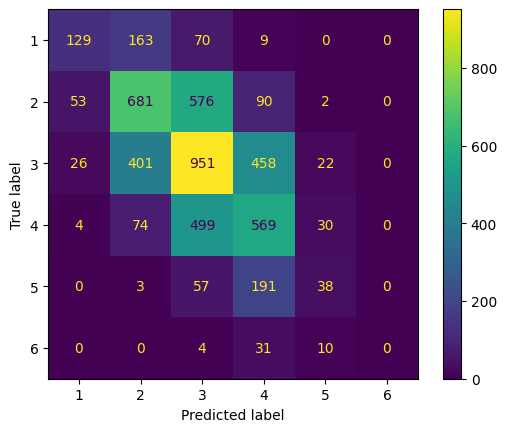

Valid F1 score: 0.453561
Valid Cohen kappa score: 0.244730


In [7]:
predictions_valid = model.predict(X_test)

cm = confusion_matrix(y_test, predictions_valid, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

f1 = f1_score(y_test, predictions_valid, average="weighted")
print(f"Valid F1 score: {f1:.6f}")
kappa = cohen_kappa_score(y_test, predictions_valid)
print(f"Valid Cohen kappa score: {kappa:.6f}")



In [8]:
# Keep original intent: remove classifier step to reuse fitted vectorizer+feature selection as a transformer.
# BUGFIX: ensure we copy steps safely.
model_steps = list(model.steps)
model_steps.pop()  # remove ('clf', LinearSVC())
new_pipeline = Pipeline(model_steps)

# Confirm transformer works
_ = new_pipeline.transform(X_train[:5])



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.162511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 397121
[LightGBM] [Info] Number of data points in the train set: 10435, number of used features: 5616
[LightGBM] [Info] Start training from score -2.628856
[LightGBM] [Info] Start training from score -1.298900
[LightGBM] [Info] Start training from score -1.017825
[LightGBM] [Info] Start training from score -1.475128
[LightGBM] [Info] Start training from score -2.877896
[LightGBM] [Info] Start training from score -4.753111
LGB Train F1 score: 0.737415
LGB Train Cohen kappa score: 0.637785


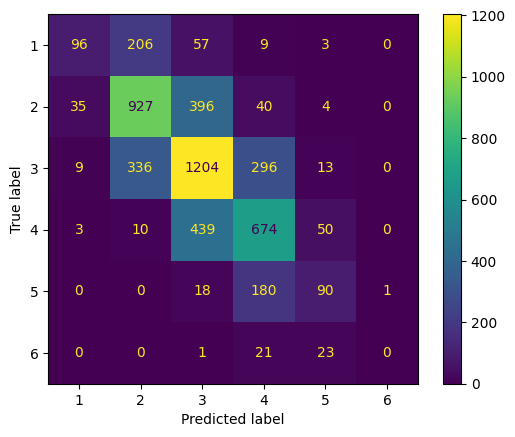

LGB Valid F1 score: 0.571632
LGB Valid Cohen kappa score: 0.414742


In [9]:
import lightgbm as lgb

params = {
    "n_estimators": 195,
    "num_leaves": 6,
    "min_child_samples": 3,
    "learning_rate": 0.06518970520093895,
    "max_bin": 511,
    "colsample_bytree": 0.9699010403795221,
    "reg_alpha": 0.028218191448367104,
    "reg_lambda": 0.855160569748305,
}

X_train_vector = new_pipeline.transform(X_train)
X_test_vector = new_pipeline.transform(X_test)

lgb_model = lgb.LGBMClassifier(**params)
lgb_model.fit(X_train_vector, y_train)

pred_train_lgb = lgb_model.predict(X_train_vector)
f1 = f1_score(y_train, pred_train_lgb, average="weighted")
print(f"LGB Train F1 score: {f1:.6f}")
kappa = cohen_kappa_score(y_train, pred_train_lgb)
print(f"LGB Train Cohen kappa score: {kappa:.6f}")

pred_valid_lgb = lgb_model.predict(X_test_vector)
cm = confusion_matrix(y_test, pred_valid_lgb, labels=[x for x in range(1, 7)])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=[x for x in range(1, 7)]
)
disp.plot()
plt.show()

f1 = f1_score(y_test, pred_valid_lgb, average="weighted")
print(f"LGB Valid F1 score: {f1:.6f}")
kappa = cohen_kappa_score(y_test, pred_valid_lgb)
print(f"LGB Valid Cohen kappa score: {kappa:.6f}")



In [10]:
# Original CV block preserved but left inactive (as in provided code) to avoid long runtimes.
"""
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)

f1_scores = []
kappa_scores = []
models = []
predictions = []

for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model_cv = Pipeline([
        ('Vectorizer', TfidfVectorizer()),
        ('feature_selection', SelectFromModel(ExtraTreesClassifier(random_state=0, n_jobs=-1))),
        ('clf', LinearSVC())
    ])
    model_cv.fit(X_train_fold, y_train_fold)
    models.append(model_cv)

    predictions_fold = model_cv.predict(X_test_fold)
    predictions.append(predictions_fold)

    f1_scores.append(f1_score(y_test_fold, predictions_fold, average='weighted'))
    kappa_scores.append(cohen_kappa_score(y_test_fold, predictions_fold))

print(f'Mean F1 score across {n_splits} folds: {np.mean(f1_scores)}')
print(f'Mean Cohen kappa score across {n_splits} folds: {np.mean(kappa_scores)}')
"""



"\nn_splits = 5\nskf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)\n\nf1_scores = []\nkappa_scores = []\nmodels = []\npredictions = []\n\nfor train_index, test_index in skf.split(X, y):\n    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]\n    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]\n\n    model_cv = Pipeline([\n        ('Vectorizer', TfidfVectorizer()),\n        ('feature_selection', SelectFromModel(ExtraTreesClassifier(random_state=0, n_jobs=-1))),\n        ('clf', LinearSVC())\n    ])\n    model_cv.fit(X_train_fold, y_train_fold)\n    models.append(model_cv)\n\n    predictions_fold = model_cv.predict(X_test_fold)\n    predictions.append(predictions_fold)\n\n    f1_scores.append(f1_score(y_test_fold, predictions_fold, average='weighted'))\n    kappa_scores.append(cohen_kappa_score(y_test_fold, predictions_fold))\n\nprint(f'Mean F1 score across {n_splits} folds: {np.mean(f1_scores)}')\nprint(f'Mean Cohen kappa score 

In [11]:
test = pd.read_csv(
    "/kaggle/input/learning-agency-lab-automated-essay-scoring-2/test.csv"
)

DESCRIPTION = test["full_text"].astype(str)
DESCRIPTION = DESCRIPTION.apply(remove_punctuations)
DESCRIPTION = DESCRIPTION.apply(remove_html)
DESCRIPTION = DESCRIPTION.apply(remove_url)
DESCRIPTION = DESCRIPTION.apply(remove_emoji)
test["text"] = DESCRIPTION

test.head()



,essay_id,full_text,text
0,d550b2d,The face was not created by aliens because the...,the face was not created by aliens because the...
1,0c10954,Hello my name is Luke Bomberger and I was seag...,hello my name is luke bomberger and i was seag...
2,ef04816,The technology to read the emotional expressio...,the technology to read the emotional expressio...
3,88ab8d9,Do you ever wonder how many soomething is or h...,do you ever wonder how many soomething is or h...
4,cee8c0f,This story is about discovering mars. Witch is...,this story is about discovering mars witch is ...


In [12]:
# Inference for submission
test_vector = new_pipeline.transform(test["text"].astype(str))
predictions = lgb_model.predict(test_vector).astype(int)

# Safety: scores must be in [1, 6]
predictions = np.clip(predictions, 1, 6)
predictions[:10], predictions.min(), predictions.max()



(array([3, 2, 3, 3, 1, 3, 3, 4, 3, 3]), 1, 6)

In [13]:
# Kept as inactive, as in original.
"""
probabilities = []
for model in models:
    decision_scores = model.decision_function(test['text'])
    proba = 1 / (1 + np.exp(-decision_scores))
    probabilities.append(proba)

probabilities = np.mean(probabilities, axis=0)
predictions = np.argmax(probabilities, axis=1) + 1
print(predictions)
"""



"\nprobabilities = []\nfor model in models:\n    decision_scores = model.decision_function(test['text'])\n    proba = 1 / (1 + np.exp(-decision_scores))\n    probabilities.append(proba)\n\nprobabilities = np.mean(probabilities, axis=0)\npredictions = np.argmax(probabilities, axis=1) + 1\nprint(predictions)\n"

In [14]:
submission = pd.read_csv(
    "/kaggle/input/learning-agency-lab-automated-essay-scoring-2/sample_submission.csv"
)

# BUGFIX: ensure row alignment with sample submission by essay_id ordering.
# (sample_submission already has the correct essay_id order; we map predictions accordingly)
if len(submission) != len(predictions):
    raise ValueError(
        f"Submission rows ({len(submission)}) != predictions ({len(predictions)})"
    )

submission["score"] = predictions
submission.to_csv("submission.csv", index=False)
print(submission.head())
print("Wrote submission.csv with shape:", submission.shape)

  essay_id  score
0  d550b2d      3
1  0c10954      2
2  ef04816      3
3  88ab8d9      3
4  cee8c0f      1
Wrote submission.csv with shape: (1731, 2)
